In [1]:
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import numpy as np

import random

def set_seed(seed):
    """Sets the seed for reproducibility."""
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if using multi-GPU.
        
    np.random.seed(seed)  # Numpy module.
    random.seed(seed)  # Python's random module.
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False

set_seed(1000)

# Set this for autonaming of plots
rest_type = 'all'

In [244]:
# Set this to the type of restaurant for auto-naming of files

# Import pre-split datasets for train, val and test cycles
df_train = pd.read_csv('./data/midwest/big-train-sampled.csv')
df_val = pd.read_csv('./data/midwest/big-val-sampled.csv')
df_test = pd.read_csv('./data/midwest/big-test-sampled.csv')

#df_train = pd.read_csv('./data/midwest/big-train-sampled.csv')
#df_val = pd.read_csv('./data/midwest/big-val-sampled.csv')
#df_test = pd.read_csv('./data/midwest/big-test-sampled.csv')

In [245]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def lemmatize_tokens(tokens, lemmatizer, pos_tags=False):
    lemmatized_text = []

    for token in tokens:
        lemma = lemmatizer.lemmatize(token)
        lemmatized_text.append(lemma)
        
    return lemmatized_text

def preprocess_text(text):
    # Maybe there's a better way to do this, but it gets hung up on reviews that are just integers 
    # I don't know why someone would leave such a review but there are a few
    text = str(text) 

    # This appears in some reviews
    text = text.replace('(Translated by Google)', ' ')
    text = text.replace('\n', ' ')

    # Make lowercase and remove puncuation 
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)

    tokens = word_tokenize(text)

    return tokens
    #return lemmatize_tokens(tokens=tokens, lemmatizer=WordNetLemmatizer())

## Get stopwords from nltk
stop_words = list(stopwords.words('english')) 

df_train['tokens'] = df_train['text'].apply(preprocess_text)
df_val['tokens'] = df_val['text'].apply(preprocess_text)
df_test['tokens'] = df_test['text'].apply(preprocess_text)

In [246]:
def pnn(n):
    if n in {1,2}: return 0 # negative
    elif n in {4,5}: return 2 # positive
    else: return 1 # "neutral"

def minus1(n):
    return n-1
    
df_train['pnn'] = df_train['rating'].apply(pnn)
df_val['pnn'] = df_val['rating'].apply(pnn)
df_test['pnn'] = df_test['rating'].apply(pnn)

In [247]:
print('Train set sample')
print(df_train.sample(5))
print()

print('Eval set sample')
print(df_val.sample(5))
print()


print('Test set sample')
print(df_test.sample(5))
print()

Train set sample
         rating                                               text  \
327608        5  Great food, very energetic staff, and a friend...   
1308299       5  What a WONDERFUL experience! Staff was truely ...   
1506820       4  Girls are always pleasant!  1/2 off appetizers...   
878287        4                                          Good food   
959489        5  Always great food, friendly service and good v...   

                             type  \
327608       Breakfast restaurant   
1308299   Small plates restaurant   
1506820        Takeout Restaurant   
878287                 Restaurant   
959489   Southern restaurant (US)   

                                                    tokens  pnn  
327608   [great, food, very, energetic, staff, and, a, ...    2  
1308299  [what, a, wonderful, experience, staff, was, t...    2  
1506820  [girls, are, always, pleasant, 12, off, appeti...    2  
878287                                        [good, food]    2  
959489   

In [249]:
# create dict from review text
# This can take awhile
df_dict = dict()
for review in df_train['tokens']:
    for word in review:
        if word in df_dict:
            df_dict[word] += 1

        else: 
            df_dict[word] = 1

# sort by most common appearing words
df_dict = {key: value for key, value in df_dict.items() if value > 1}
df_dict = list(dict(sorted(df_dict.items(), key=lambda item: item[1], reverse=True)))

# Create vocab as dict word:idx ordered by most common appearance
vocab = dict()
i = 1

for word in df_dict:
    vocab[word] = i
    i += 1

In [250]:
# This will create the embedding matrix
# This takes in a dictionary, which should be influenced by the review data
def load_glove_embeddings(glove_file, dictionary):
    embeddings = {}
    
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in dictionary:
                vector = np.asarray(values[1:], dtype='float32')
                embeddings[word] = vector

    return embeddings

def create_embedding_matrix(glove_embeddings, vocab):
    embedding_dim = glove_len
    num_embeddings = len(vocab) + 1
    embedding_matrix = np.zeros((num_embeddings, embedding_dim))
    
    for word, idx in vocab.items():
        if word not in glove_embeddings:
            continue
            
        embedding_vector = glove_embeddings.get(word)
        if embedding_vector is not None:
            embedding_matrix[idx] = embedding_vector
            
    return torch.tensor(embedding_matrix, dtype=torch.float32)

## Set directory of glove file and load the embeddings
glove_file = './glove/glove.6B.100d.txt' 
glove_embeddings = load_glove_embeddings(glove_file, vocab)

## Set dim of GloVe vectors (we'll use the 50d)
glove_len = len(glove_embeddings['the'])

# Create embedding matrix
embedding_matrix = create_embedding_matrix(glove_embeddings, vocab)

vocab_size, embedding_dim = list(embedding_matrix.size())


In [ ]:
import pickle

def save_dictionary_pickle(dictionary, filename):
    """Saves a dictionary to a pickle file."""
    with open(filename, 'wb') as f:  # 'wb' for binary write
        pickle.dump(dictionary, f)

def load_dictionary_pickle(filename):
    """Loads a dictionary from a pickle file."""
    with open(filename, 'rb') as f:  # 'rb' for binary read
        return pickle.load(f)

save_dictionary_pickle(embedding_matrix, 'embd_mat.pkl')

In [251]:
# Check that the matrix is the right thing
for index, (key, value) in enumerate(vocab.items()):
        if index < 5:
            print(value, key)
            print()

            print('embedding mat')
            print(embedding_matrix[value])
            
            print('glove emb')
            print(glove_embeddings[key])
            print()
        else:
            break

1 the

embedding mat
tensor([-0.0382, -0.2449,  0.7281, -0.3996,  0.0832,  0.0440, -0.3914,  0.3344,
        -0.5755,  0.0875,  0.2879, -0.0673,  0.3091, -0.2638, -0.1323, -0.2076,
         0.3340, -0.3385, -0.3174, -0.4834,  0.1464, -0.3730,  0.3458,  0.0520,
         0.4495, -0.4697,  0.0263, -0.5415, -0.1552, -0.1411, -0.0397,  0.2828,
         0.1439,  0.2346, -0.3102,  0.0862,  0.2040,  0.5262,  0.1716, -0.0824,
        -0.7179, -0.4153,  0.2033, -0.1276,  0.4137,  0.5519,  0.5791, -0.3348,
        -0.3656, -0.5486, -0.0629,  0.2658,  0.3020,  0.9977, -0.8048, -3.0243,
         0.0125, -0.3694,  2.2167,  0.7220, -0.2498,  0.9214,  0.0345,  0.4674,
         1.1079, -0.1936, -0.0746,  0.2335, -0.0521, -0.2204,  0.0572, -0.1581,
        -0.3080, -0.4162,  0.3797,  0.1501, -0.5321, -0.2055, -1.2526,  0.0716,
         0.7056,  0.4974, -0.4206,  0.2615, -1.5380, -0.3022, -0.0734, -0.2831,
         0.3710, -0.2522,  0.0162, -0.0171, -0.3898,  0.8742, -0.7257, -0.5106,
        -0.5203, -0

In [252]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_size, embedding_matrix):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(embedding_matrix) #load the pretrained embeddings.
        
        # Freeze parameters from glove embedding matrix
        self.embedding.weight.requires_grad = False 

        # bidirectional LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, dropout=0.3, batch_first=True, bidirectional=True) 
        self.fc = nn.Linear(hidden_size * 2, output_size) 

    def forward(self, x):
        embedded = self.embedding(x)
        out, _ = self.lstm(embedded)
        out = self.fc(out[:, -1, :])
        
        return out


In [253]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)

# Set model parameters
hidden_size = 196 # Tried larger size here, not sure
num_layers = 2
output_size = 3  # Number of output classes: positive/negative/neutral

## Idea is to add an attention layer
model = LSTMModel(vocab_size, embedding_dim, hidden_size, num_layers, output_size, embedding_matrix)
model.to(device)



Device: cuda


LSTMModel(
  (embedding): Embedding(76322, 100)
  (lstm): LSTM(100, 196, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=392, out_features=3, bias=True)
)

In [254]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
LSTMModel                                --
├─Embedding: 1-1                         (7,632,200)
├─LSTM: 1-2                              1,392,384
├─Linear: 1-3                            1,179
Total params: 9,025,763
Trainable params: 1,393,563
Non-trainable params: 7,632,200

In [255]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

In [256]:
# Converts a string to vocab indices, and pads/truncates all reviews to be 50 tokens
def stringerizer(tokens, max_length=64):
    ids = []
    for word in tokens:
        if (word not in glove_embeddings) or (word not in vocab):
            continue

        else: ids.append(vocab[word])

    return ids[:max_length] + [0] * (max_length - len(ids))

In [257]:
X_train = []
y_train = df_train['pnn']

X_val = []
y_val = torch.tensor(df_val['pnn'].tolist(), dtype=torch.long)

X_test = []
y_train = torch.tensor(df_test['pnn'], dtype=torch.long)

for review in df_train['tokens']:
    X_train.append(stringerizer(review, max_length=128))

for review in df_val['tokens']:
    X_val.append(stringerizer(review, max_length=128))

for review in df_test['tokens']:
    X_test.append(stringerizer(review, max_length=128))

X_train = torch.tensor(X_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

train_dataset = SentimentDataset(X_train, df_train['pnn'])
val_dataset = SentimentDataset(X_val, df_val['pnn'])
test_dataset = SentimentDataset(X_test, df_test['pnn'])

In [263]:
import seaborn as sns
import datetime
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    
    current_time = datetime.datetime.now()
    file_name = f'./sshots/model-{rest_type}-{current_time.strftime("%Y-%m-%d--%H%m")}.png'
    plt.savefig(file_name)
    
    plt.show()
    return

def runtime(start_time):
    end_time = time.time()
    s = end_time - start_time

    h = s // 3600
    s = s - 3600*h

    m = s // 60
    s = s - 60*m

    print(f'Total runtime: {int(h)} hr {int(m)} min {s:.1f} sec')
    return 

In [264]:
from sklearn.utils import class_weight

# Ratings are not evenly distributed, this creates class weights
def calculate_class_weights(labels):
    class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    return torch.tensor(class_weights, dtype=torch.float)

In [265]:
batch_size = 256
learning_rate = .001
weight_decay = .01

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# Define loss function and optimizer
class_weights = calculate_class_weights(df_train['pnn'].tolist()).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print('Class weights:', class_weights)

Class weights: tensor([2.6587, 3.3778, 0.4296], device='cuda:0')


In [266]:
def evaluate_model(model, dataloader):
    # Put in evaluation mode
    print('Evaluating...', end='\r')
    model.eval()
    
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            output = model(X)
            
            pred_labels = torch.argmax(output, dim=1)
            
            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    ## Accuracy and F1 used to determine early exit
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return acc, f1

In [267]:
def early_stopping(model, train_dataloader, val_dataloader, optimizer, epochs=100, patience=5, max_grad_norm=1.0, device='cuda'):
    # Keep track of some data
    start_time = time.time()
    accs, f1s = [], []

    # Learning rate scheduler
    #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)  # Reduce LR every 10 epochs by 0.1
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

    # Set best value as low as possible to start
    best_val_f1 = -np.inf
    patience_counter = 0

    for epoch in range(epochs):
        # Put model in train mode
        model.train()
        train_loss = 0
    
        for X, y in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}"):
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            
            ## Evaluate model at the inputs
            output = model(X)
            
            ## Evaluate loss and backpropogate
            loss = criterion(output, y)
            loss.backward()

            train_loss += loss.item()

            ## Clip gradient
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            ## Stepforward the optimizer and scheduler
            optimizer.step()
            scheduler.step()

        # Keep track of loss
        loss = train_loss / len(train_dataloader)
        
        # Validation cycle
        val_acc, val_f1 = evaluate_model(model=model, dataloader=val_dataloader)
        
        accs.append(val_acc)
        f1s.append(val_f1)

        # Keep track of progress
        print(f'Train loss: {loss:.5f} | Val acc: {100*val_acc:.2f}%, F1 {val_f1:.5f}')
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            
            # Save the best model
            torch.save(model.state_dict(), f'./saved-models/LSTM-{rest_type}-big.pth')
            print('--New best--')
            
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping triggered')
                #plot_lists_with_colors(accs, f1s, label1="Validation accuracy", label2="Validation F1")
                break 

    # Print total runtime
    runtime(start_time)

    # Load the best model and return it
    model.load_state_dict(torch.load(f'./saved-models/LSTM-{rest_type}-big.pth'))
    return model

In [268]:
model = early_stopping(model=model, 
                       train_dataloader=train_dataloader, 
                       val_dataloader=val_dataloader, 
                       optimizer=optimizer, 
                       epochs=500, 
                       patience=5,
                       max_grad_norm=1.0,
                       device=device)

Epoch 1: 100%|██████████████████████████████████████████████| 6250/6250 [12:07<00:00,  8.59it/s]


Train loss: 0.66576 | Val acc: 82.26%, F1 0.84402
--New best--


Epoch 2: 100%|██████████████████████████████████████████████| 6250/6250 [12:07<00:00,  8.59it/s]


Train loss: 0.54986 | Val acc: 83.19%, F1 0.85084
--New best--


Epoch 3: 100%|██████████████████████████████████████████████| 6250/6250 [12:09<00:00,  8.57it/s]


...

Epoch 8: 100%|██████████████████████████████████████████████| 6250/6250 [11:50<00:00,  8.80it/s]


Train loss: 0.47896 | Val acc: 83.77%, F1 0.85711


Epoch 9: 100%|██████████████████████████████████████████████| 6250/6250 [11:54<00:00,  8.75it/s]


Train loss: 0.46959 | Val acc: 83.83%, F1 0.85666
Early stopping triggered
Total runtime: 1 hr 53 min 28.2 sec


/tmp/ipykernel_1889287/3625289809.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./saved-models/LSTM-{rest_type}-big.pth'))


100%|███████████████████████████████████████████████████████| 1563/1563 [00:38<00:00, 40.25it/s]


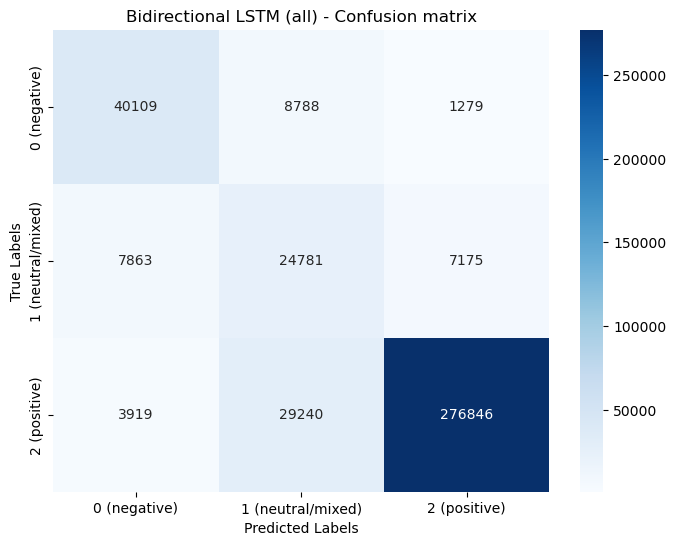

Test acc: 85.43%, F1 0.86750


In [269]:
def make_prediction(model, dataloader):
    model.eval()
    
    all_probs, all_preds, all_labels = [], [], []
    
    with torch.no_grad():
        for X, y in tqdm(dataloader):
            X = X.to(device)
            y = y.to(device)
            
            output = model(X)

            pred_labels = torch.argmax(output, dim=1)
            
            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            probs = torch.softmax(output, dim=1).cpu().numpy()
            all_probs.extend(probs)

    plot_confusion_matrix(cm=confusion_matrix(np.array(df_test['pnn']), np.array(all_preds)), 
                            classes=['0 (negative)', '1 (neutral/mixed)', '2 (positive)'], 
                            title=f'Bidirectional LSTM ({rest_type}) - Confusion matrix')

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return all_probs, acc, f1 

# Write probs column and save df
probs, acc, f1 = make_prediction(model=model, dataloader=test_dataloader)

df_test['Bidirectional LSTM - probs'] = probs
print(f'Test acc: {100*acc:.2f}%, F1 {f1:.5f}')


df_test.to_csv('./data/midwest/big-test--sampled.csv', index=False)

In [272]:
df_test.head()

,rating,text,type,pnn,bert - probs,roberta - probs,Bidirectional LSTM - probs
0,5,love the 200 happyhour 2pm till 5pm thn again ...,Takeout Restaurant,2,[0.02318591 0.03596894 0.94084525],[5.0048920e-04 4.9842149e-03 9.9451524e-01],"[0.005154241, 0.05328341, 0.94156235]"
1,4,the food is decent and the cheese curds are aw...,Restaurant,2,[0.00246261 0.01222768 0.98530966],[0.00142059 0.03283421 0.9657452 ],"[0.010283194, 0.58611655, 0.40360028]"
2,4,very helpful,Restaurant,2,[0.04512969 0.08537012 0.86950016],[0.00179214 0.02205463 0.97615325],"[0.010874874, 0.14798339, 0.8411417]"
3,5,we had the best dinner here great open spot th...,Asian restaurant,2,[0.00457231 0.0160854 0.97934234],[1.06368854e-04 1.35732337e-03 9.98536229e-01],"[0.00038917517, 0.0033940626, 0.9962167]"
4,5,my new fav,Restaurant,2,[0.03288918 0.03597173 0.9311391 ],[0.0012976 0.00777086 0.9909315 ],"[0.05359737, 0.2582511, 0.68815154]"
